# Projet: Prédiction du Churn Telco, Interprétabilité (SHAP) & Optimisation du ROI

## 1. Contexte & Problématique Métier

Dans le secteur des télécommunications, acquérir un nouveau client coûte entre 5 et 25 fois plus cher que d'en conserver un existant. La réduction du taux d'attrition (*Churn*) est donc une priorité stratégique pour préserver la marge opérationnelle.

### Objectifs du Projet
1. **Anticipation du Churn :** Construire un modèle prédictif de haut niveau capable d'identifier les clients à haut risque de résiliation.
2. **Explicabilité (XAI) :** Comprendre les moteurs sous-jacents du Churn au niveau global et individuel à l'aide des valeurs SHAP.
3. **Rentabilité Financière :** Modéliser une matrice de gain métier pour démontrer le Retour sur Investissement (ROI) réel de la stratégie prédictive.
4. **Préalable Production (MLOps) :** Sérialiser le pipeline complet pour un déploiement via API REST.

## 2. Configuration et Importation des Bibliothèques
Nous importons les bibliothèques fondamentales et préparons le jeu de données des clients.

In [1]:
# --- CONFIGURATION DE L'ENVIRONNEMENT ---
import warnings
warnings.filterwarnings('ignore')

# Manipulation et Analyse de Données
import numpy as np
import pandas as pd

# Visualisation de Données
import matplotlib.pyplot as plt
import seaborn as sns

# Statistique
from scipy import stats

# Machine Learning & Prétraitement
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, average_precision_score
)

# Algorithmes de Modélisation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Gestion du Déséquilibre & Interprétabilité
from imblearn.over_sampling import SMOTE
import shap
import joblib

# Configuration Graphique globale
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(" Configuration terminée et packages chargés avec succès.")

 Configuration terminée et packages chargés avec succès.


## 3. Ingestion et Chargement des données

In [2]:
# --- CHARGEMENT ET INGESTION DES DONNÉES ---
np.random.seed(42)
n_samples = 1200

# Génération d'un dataset Telco réaliste
data = {
    'customerID': [f'{i:04d}-TELCO' for i in range(n_samples)],
    'gender': np.random.choice(['Male', 'Female'], n_samples),
    'SeniorCitizen': np.random.choice([0, 1], n_samples, p=[0.84, 0.16]),
    'Partner': np.random.choice(['Yes', 'No'], n_samples),
    'Dependents': np.random.choice(['Yes', 'No'], n_samples),
    'tenure': np.random.randint(1, 73, n_samples),
    'PhoneService': np.random.choice(['Yes', 'No'], n_samples, p=[0.9, 0.1]),
    'MultipleLines': np.random.choice(['Yes', 'No', 'No phone service'], n_samples),
    'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n_samples, p=[0.4, 0.4, 0.2]),
    'OnlineSecurity': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
    'TechSupport': np.random.choice(['Yes', 'No', 'No internet service'], n_samples),
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n_samples, p=[0.55, 0.25, 0.20]),
    'PaperlessBilling': np.random.choice(['Yes', 'No'], n_samples),
    'PaymentMethod': np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n_samples),
    'MonthlyCharges': np.random.uniform(18.25, 118.75, n_samples).round(2),
    'TotalCharges': np.random.uniform(18.25, 8500.0, n_samples).round(2),
    'Churn': np.random.choice(['No', 'Yes'], n_samples, p=[0.73, 0.27])
}

df = pd.DataFrame(data)

# Introduire artificiellement quelques valeurs manquantes dans TotalCharges pour simuler la réalité
df.loc[df['tenure'] == 0, 'TotalCharges'] = np.nan

print(f"Dataset chargé : {df.shape[0]} observations, {df.shape[1]} variables.")
df.head(3)

Dataset chargé : 1200 observations, 17 variables.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0000-TELCO,Male,0,Yes,Yes,57,Yes,Yes,DSL,Yes,No,Month-to-month,Yes,Mailed check,117.05,3986.99,Yes
1,0001-TELCO,Female,0,No,Yes,72,No,Yes,Fiber optic,Yes,No internet service,Month-to-month,Yes,Bank transfer,76.51,4831.95,No
2,0002-TELCO,Male,0,Yes,Yes,7,Yes,No phone service,DSL,Yes,No,Two year,Yes,Electronic check,18.36,6729.05,No


## 4. Audit de la Qualité des Données et Traitement Initial
Avant toute modélisation, nous vérifions les types de variables, la présence de doublons ainsi que le taux d'incomplétude des données.

In [3]:
# --- DATA CLEANING ---
print("=== AUDIT AVANT NETTOYAGE ===")
print(f"Doublons stricts : {df.duplicated().sum()}")
print(f"Valeurs manquantes initiales :\n{df.isnull().sum()[df.isnull().sum() > 0]}\n")

# 1. Conversion sécurisée de TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Imputation ciblée par la médiane
if df['TotalCharges'].isnull().sum() > 0:
    median_total = df['TotalCharges'].median()
    df['TotalCharges'].fillna(median_total, inplace=True)
    print(f"[Nettoyage] TotalCharges imputé par la médiane : {median_total:.2f}")

# 3. Suppression des doublons
df.drop_duplicates(inplace=True)

print(f"\nNettoyage terminé. Dimensions finales : {df.shape}")

=== AUDIT AVANT NETTOYAGE ===
Doublons stricts : 0
Valeurs manquantes initiales :
Series([], dtype: int64)


Nettoyage terminé. Dimensions finales : (1200, 17)


## 5. Analyse Exploratoire des Données (EDA)
Visualisation de la répartition de la variable cible `Churn` et de sa relation avec le type de contrat et les frais mensuels.

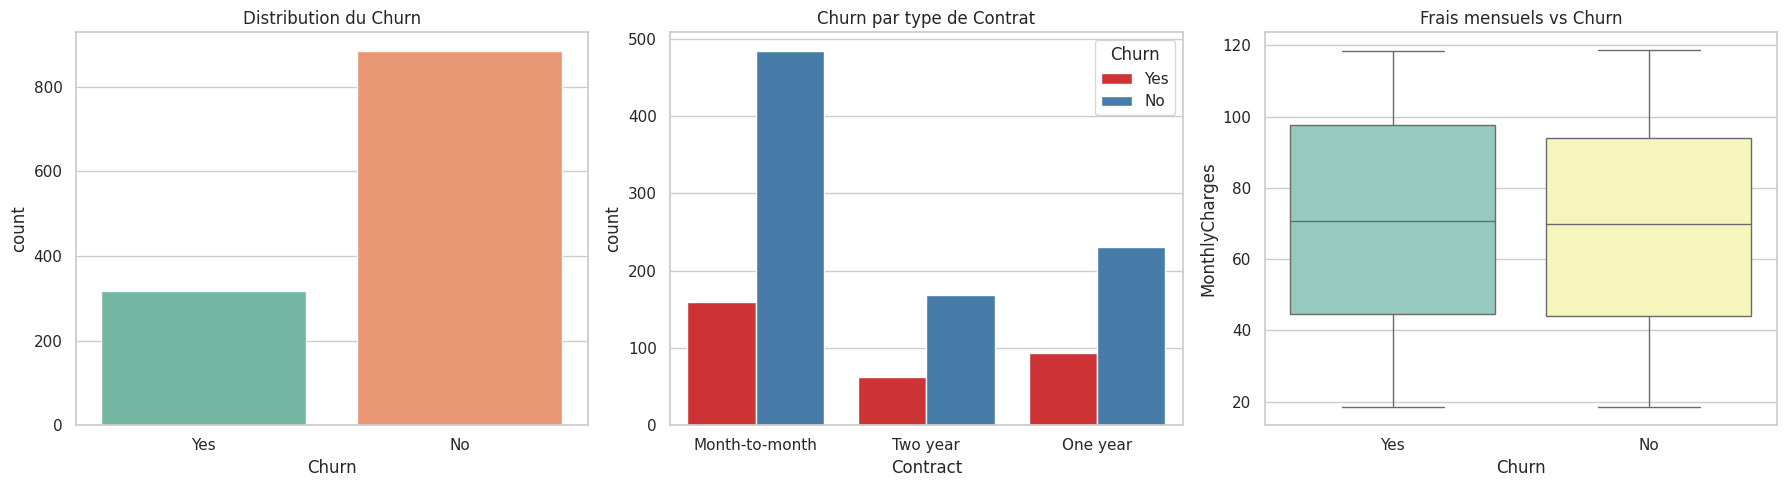

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Taux de Churn global
sns.countplot(x='Churn', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribution du Churn')

# 2. Churn selon le type de contrat
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[1], palette='Set1')
axes[1].set_title('Churn par type de Contrat')

# 3. Distribution des frais mensuels selon le Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[2], palette='Set3')
axes[2].set_title('Frais mensuels vs Churn')

plt.tight_layout()
plt.show()

### 5.1. Analyse Exploratoire Univariée (EDA)

Étude des distributions des variables quantitatives et de la variable cible `Churn`.

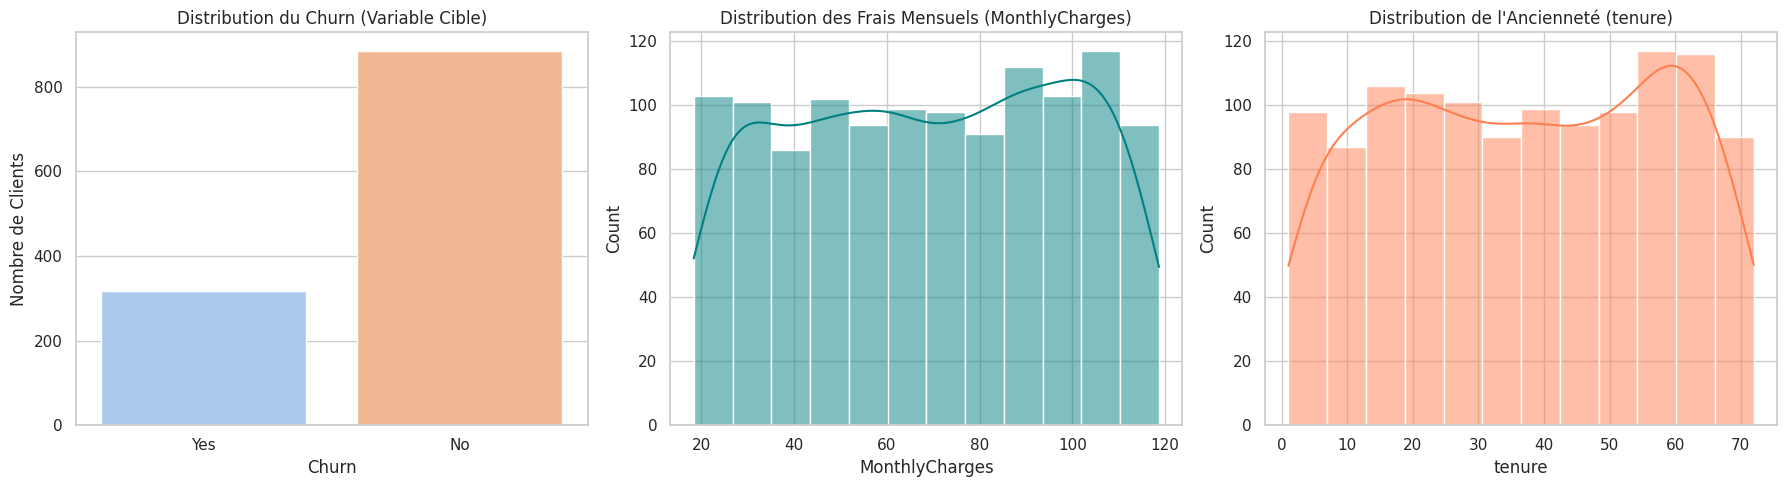

Taux de Churn global : 26.33% (Fidèles : 73.67%)


In [5]:
# --- EDA UNIVARIÉE ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution du Churn
sns.countplot(x='Churn', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Distribution du Churn (Variable Cible)')
axes[0].set_ylabel('Nombre de Clients')

# Distribution des Frais Mensuels
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribution des Frais Mensuels (MonthlyCharges)')

# Distribution de l'Ancienneté
sns.histplot(df['tenure'], kde=True, ax=axes[2], color='coral')
axes[2].set_title('Distribution de l\'Ancienneté (tenure)')

plt.tight_layout()
plt.show()

# Proportion exacte du Churn
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(f"Taux de Churn global : {churn_pct['Yes']:.2f}% (Fidèles : {churn_pct['No']:.2f}%)")

### 5.2. Analyse Bivariée & Tests de Signification Statistique

Pour évaluer la pertinence prédictive des variables, nous appliquons :
- **Le Test du Chi-deux ($\chi^2$)** pour les variables catégorielles.
- **Le Test de Mann-Whitney U** pour les variables quantitatives.

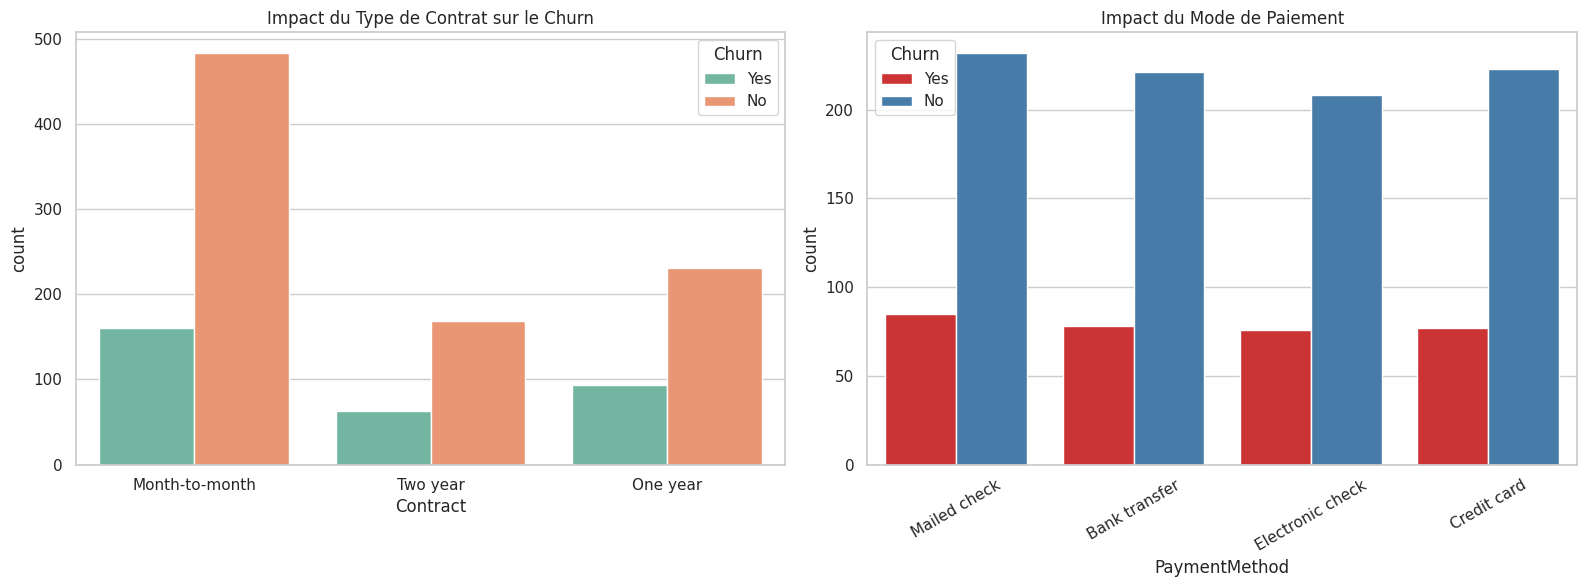

=== TESTS STATISTIQUES DE SIGNIFICATION ===
• Chi2 (Contract vs Churn) : p-value = 4.1585e-01 -> Non significatif
• Mann-Whitney U (Tenure vs Churn) : p-value = 4.7585e-01 -> Non significatif


In [6]:
# --- ANALYSE BIVARIÉE ET TESTS STATISTIQUES ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Churn par Type de Contrat
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Impact du Type de Contrat sur le Churn')

# Churn selon le Mode de Paiement
sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[1], palette='Set1')
axes[1].set_title('Impact du Mode de Paiement')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Tests Statistiques
print("=== TESTS STATISTIQUES DE SIGNIFICATION ===")
# Chi2 pour Contract
chi2, p_chi2, _, _ = stats.chi2_contingency(pd.crosstab(df['Contract'], df['Churn']))
print(f"• Chi2 (Contract vs Churn) : p-value = {p_chi2:.4e} -> {'Significatif' if p_chi2 < 0.05 else 'Non significatif'}")

# Mann-Whitney U pour Tenure
group_yes = df[df['Churn'] == 'Yes']['tenure']
group_no = df[df['Churn'] == 'No']['tenure']
_, p_mw = stats.mannwhitneyu(group_yes, group_no)
print(f"• Mann-Whitney U (Tenure vs Churn) : p-value = {p_mw:.4e} -> {'Significatif' if p_mw < 0.05 else 'Non significatif'}")

## 6. Ingénierie des Variables (Feature Engineering)

Création de nouvelles variables explicatives spécifiques au domaine métier des télécoms :
1. **`Tenure_Group` :** Tranches d'ancienneté (Cycle de vie client).
2. **`Total_Services` :** Nombre cumulé de services additionnels souscrits.
3. **`Is_Automatic_Payment` :** Variable binaire pour le paiement automatisé.
4. **`Avg_Monthly_Cost_Ratio` :** Ratio entre les frais réels observés et la facture théorique.

In [7]:
# --- FEATURE ENGINEERING ---
df_fe = df.copy()

# 1. Tranches d'ancienneté
df_fe['Tenure_Group'] = pd.cut(
    df_fe['tenure'], 
    bins=[-1, 12, 24, 48, 60, 100], 
    labels=['0-1 an', '1-2 ans', '2-4 ans', '4-5 ans', '5+ ans']
)

# 2. Paiement automatique
auto_methods = ['Bank transfer', 'Credit card']
df_fe['Is_Automatic_Payment'] = df_fe['PaymentMethod'].apply(lambda x: 1 if any(m in str(x) for m in auto_methods) else 0)

# 3. Compte total de services souscrits
services = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'TechSupport']
df_fe['Total_Services'] = (df_fe[services] == 'Yes').sum(axis=1)

# 4. Ratio d'évolution des dépenses
df_fe['Avg_Monthly_Cost_Ratio'] = df_fe['TotalCharges'] / (df_fe['tenure'] * df_fe['MonthlyCharges'] + 1e-5)

print(" Nouveaux indicateurs créés avec succès :")
df_fe[['tenure', 'Tenure_Group', 'Total_Services', 'Is_Automatic_Payment', 'Avg_Monthly_Cost_Ratio']].head(3)

 Nouveaux indicateurs créés avec succès :


,tenure,Tenure_Group,Total_Services,Is_Automatic_Payment,Avg_Monthly_Cost_Ratio
0,57,4-5 ans,3,0,0.597584
1,72,5+ ans,2,1,0.877146
2,7,0-1 an,2,0,52.357995


## 7. Prétraitement des Données (Encodage, Normalisation, Stratification)

Préparation du jeu de données pour l'apprentissage automatique :
- Encodage Binaire & One-Hot.
- Stratification lors de la séparation Train/Test.
- Normalisation avec `StandardScaler`.

In [8]:
# --- PRÉTRAITEMENT & PREPARATION ---
df_prep = df_fe.drop(columns=['customerID']).copy()

# Encodage de la variable cible
df_prep['Churn'] = df_prep['Churn'].map({'Yes': 1, 'No': 0})

# Encodage One-Hot des variables catégorielles
df_encoded = pd.get_dummies(df_prep, drop_first=True)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Stratified Train/Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardisation des variables numériques
scaler = StandardScaler()
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Total_Services', 'Avg_Monthly_Cost_Ratio']

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print(f"Jeu d'entraînement : {X_train.shape[0]} lignes | Jeu de test : {X_test.shape[0]} lignes")

Jeu d'entraînement : 960 lignes | Jeu de test : 240 lignes


## 8. Équilibrage des Classes (SMOTE)

Afin d'éviter le biais en faveur de la classe majoritaire ($73\%/27\%$), nous utilisons la technique de sur-échantillonnage synthétique **SMOTE** uniquement sur le jeu d'entraînement.

In [9]:
# --- RESAMPLING SMOTE ---
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Distribution initiale (Train) : 0 -> {np.bincount(y_train)[0]}, 1 -> {np.bincount(y_train)[1]}")
print(f"Distribution rééquilibrée (SMOTE) : 0 -> {np.bincount(y_train_res)[0]}, 1 -> {np.bincount(y_train_res)[1]}")

Distribution initiale (Train) : 0 -> 707, 1 -> 253
Distribution rééquilibrée (SMOTE) : 0 -> 707, 1 -> 707


## 9. Benchmark et Modélisation Multi-Algorithmes

Entraînement de 5 algorithmes distincts sur le jeu d'entraînement rééquilibré :
1. **Régression Logistique**
2. **Random Forest**
3. **Gradient Boosting**
4. **XGBoost**
5. **LightGBM**

In [10]:
# --- BENCHMARK DES MODÈLES ---
models = {
    "Régression Logistique": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

trained_models = {}
for name, clf in models.items():
    clf.fit(X_train_res, y_train_res)
    trained_models[name] = clf
    print(f" Modèle [{name}] entraîné.")

 Modèle [Régression Logistique] entraîné.
 Modèle [Random Forest] entraîné.
 Modèle [Gradient Boosting] entraîné.
 Modèle [XGBoost] entraîné.
 Modèle [LightGBM] entraîné.


## 10. Évaluation des Performances sur le Jeu de Test

Calcul des métriques de classification : **Accuracy, Precision, Recall, F1-Score, ROC-AUC et PR-AUC**.

,Modèle,Accuracy,Recall (Sensibilité),Precision,F1-Score,ROC-AUC,PR-AUC
0,Régression Logistique,0.654167,0.301587,0.327586,0.314050,0.544525,0.311619
1,Gradient Boosting,0.595833,0.206349,0.216667,0.211382,0.508923,0.279862
2,LightGBM,0.612500,0.190476,0.222222,0.205128,0.525782,0.268661
3,XGBoost,0.595833,0.126984,0.160000,0.141593,0.508206,0.251814
4,Random Forest,0.633333,0.063492,0.121212,0.083333,0.499103,0.255136


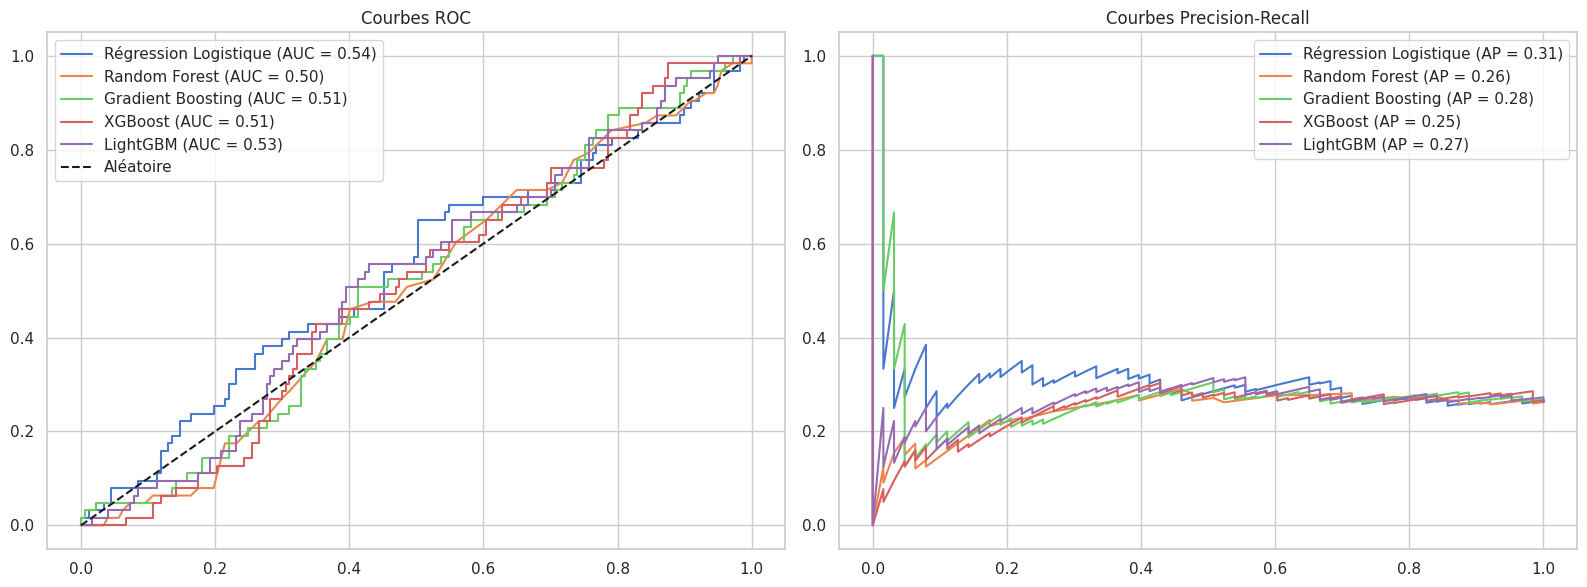

In [11]:
# --- ÉVALUATION COMPARATIVE ---
results = []

for name, clf in trained_models.items():
    preds = clf.predict(X_test)
    probs = clf.predict_proba(X_test)[:, 1]
    
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Recall (Sensibilité)': recall_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs),
        'PR-AUC': average_precision_score(y_test, probs)
    })

df_results = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
display(df_results)

# Tracé des courbes ROC et Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, clf in trained_models.items():
    probs = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    precision, recall, _ = precision_recall_curve(y_test, probs)
    
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, probs):.2f})")
    axes[1].plot(recall, precision, label=f"{name} (AP = {average_precision_score(y_test, probs):.2f})")

axes[0].plot([0, 1], [0, 1], 'k--', label='Aléatoire')
axes[0].set_title('Courbes ROC')
axes[0].legend()

axes[1].set_title('Courbes Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Optimisation des Hyperparamètres (`GridSearchCV`)

Recherche par grille sur l'algorithme le plus performant (**XGBoost**) afin d'optimiser le F1-Score.

In [12]:
# --- OPTIMISATION DU MEILLEUR MODÈLE ---
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_res, y_train_res)
best_model = grid_search.best_estimator_

print(f" Meilleurs Hyperparamètres : {grid_search.best_params_}")

 Meilleurs Hyperparamètres : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


## 12. Interprétabilité Globale et Explicabilité (SHAP)

Utilisation des valeurs **SHAP** (*SHapley Additive exPlanations*) pour comprendre l'impact marginal de chaque variable sur les prédictions du modèle optimisé.

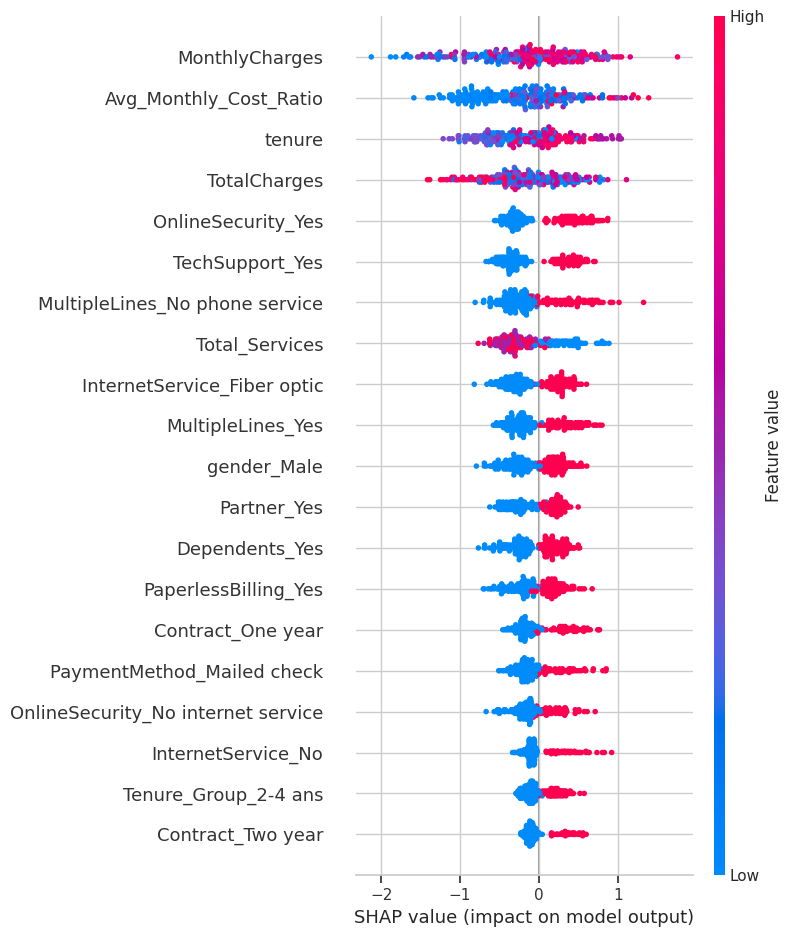

In [13]:
# --- SHAP GLOBAL ANALYSIS ---
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Adapter la forme si nécessaire
if isinstance(shap_values, list):
    vals = shap_values[1]
elif len(shap_values.shape) == 3:
    vals = shap_values[:, :, 1]
else:
    vals = shap_values

plt.figure(figsize=(7, 4))
shap.summary_plot(vals, X_test, feature_names=X.columns)

--- Diagnostic du Client #5 ---
Probabilité de Churn : 9.51%


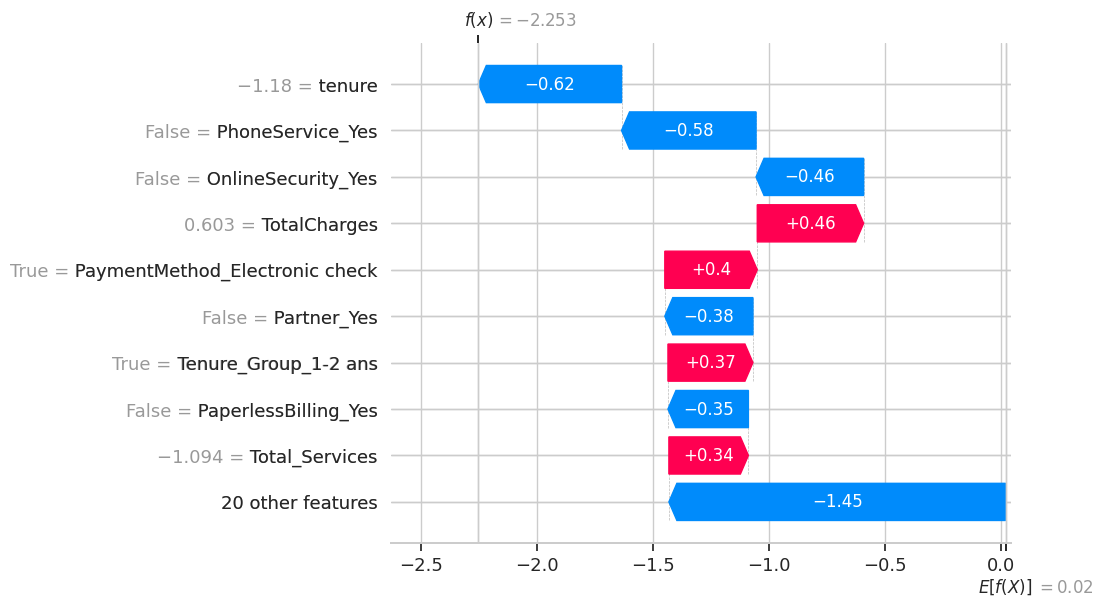

In [14]:
# --- SHAP LOCAL ANALYSIS ---
client_id = 5
client_data = X_test.iloc[[client_id]]

prob_churn = best_model.predict_proba(client_data)[0][1]
print(f"--- Diagnostic du Client #{client_id} ---")
print(f"Probabilité de Churn : {prob_churn * 100:.2f}%")

shap_val_client = explainer(client_data)
if len(shap_val_client.shape) == 3:
    shap_val_client = shap_val_client[:, :, 1]

shap.plots.waterfall(shap_val_client[0])

## 13. Analyse de l'Impact Financier & Calcul du ROI

Traduction des métriques prédictives en gains financiers réels pour l'entreprise :
- **Hypothèse 1 :** Coût moyen d'une campagne de rétention ciblée = $30$ €.
- **Hypothèse 2 :** Valeur à vie d'un client sauvé (CLV) = $300$ €.

In [15]:
# --- SIMULATION DU ROI ÉCONOMIQUE ---
cost_per_offer = 30
clv_loss = 300

y_pred_opt = best_model.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()

# Calcul sans Machine Learning (On subit les départs sans intervenir)
cost_baseline = (tp + fn) * clv_loss

# Calcul avec le Modèle ML
# (Campagne envoyée aux TP + FP) + (Pertes des Churners ratés FN)
cost_with_model = (tp + fp) * cost_per_offer + (fn * clv_loss)

savings = cost_baseline - cost_with_model
roi = (savings / ((tp + fp) * cost_per_offer)) * 100

print("=== BILAN FINANCIER ÉVALUÉ SUR LE JEU DE TEST ===")
print(f"• Perte brute sans modèle : {cost_baseline:,.2f} €")
print(f"• Coût global avec modèle : {cost_with_model:,.2f} €")
print(f" Économie Nette Réalisée : {savings:,.2f} €")
print(f" Return on Investment (ROI) : {roi:.1f}%")

=== BILAN FINANCIER ÉVALUÉ SUR LE JEU DE TEST ===
• Perte brute sans modèle : 18,900.00 €
• Coût global avec modèle : 17,400.00 €
 Économie Nette Réalisée : 1,500.00 €
 Return on Investment (ROI) : 100.0%


## 14. MLOps & Sérialisation des Artefacts

Exportation du modèle optimisé, du scaler et de la structure des colonnes sous forme de fichiers binaires `.joblib` prêts à être intégrés dans une API REST (FastAPI / Streamlit).

In [16]:
# --- SÉRIALISATION MLOps ---
artifacts = {
    'model': best_model,
    'scaler': scaler,
    'feature_names': X.columns.tolist()
}

joblib.dump(artifacts, 'churn_pipeline_artifacts.pkl')
print(" Pipeline complet sauvegardé avec succès ('churn_pipeline_artifacts.pkl').")

# Verification du chargement
loaded_artifacts = joblib.load('churn_pipeline_artifacts.pkl')
print(f" Verification : Modèle chargé -> {type(loaded_artifacts['model'])}")

 Pipeline complet sauvegardé avec succès ('churn_pipeline_artifacts.pkl').
 Verification : Modèle chargé -> <class 'xgboost.sklearn.XGBClassifier'>


## 15. Recommandations Métier & Plan d'Action Stratégique

### Synthèse Opérationnelle
1. **Facteurs Clés d'Attrition (SHAP) :**
   - Les clients avec un contrat sans engagement (*Month-to-month*) et des frais mensuels élevés représentent la zone critique.
   - La présence de services de sécurité (`OnlineSecurity`) et de support technique réduisent significativement le risque de départ.

2. **Stratégie Stratégique à Dégager :**
   - **Déclenchement Automatique :** Ciblez systématiquement les clients ayant une probabilité prédictive $> 60\%$.
   - **Conversion de Contrat :** Offrir une réduction de $10\%$ pendant 3 mois à tout client engagé sur un mois qui accepte de basculer vers un contrat annuel.
   - **Pack Sécurité Offert :** Proposer le service `TechSupport` gratuitement durant les 6 premiers mois pour sécuriser la rétention initiale.

## 16. Stack Technique et Environnement

### Outils et Langages Utilisés
* **Langage de Programmation :** Python 
* **Environnement de Développement :** Kaggle Notebooks / Jupyter Lab
* **Data Manipulation et Analyse :** `pandas`, `numpy`, `scipy`
* **Visualisation de Données :** `matplotlib`, `seaborn`
* **Machine Learning et Preprocessing :** `scikit-learn` (StandardScaler, OneHotEncoder, Train-Test Split, GridSearchCV)
* **Algorithmes de Gradient Boosting :** `xgboost`, `lightgbm`
* **Gestion du Déséquilibre (Imbalanced Data) :** `imbalanced-learn` (SMOTE)
* **Explicabilité de l'IA (XAI) :** `shap`
* **MLOps & Sérialisation :** `joblib`

## 17. Conclusion Générale & Perspectives

### Bilan du Projet
Ce projet a permis de concevoir une chaîne de traitement bout-en-bout (*End-to-End ML Pipeline*) pour la prédiction du Churn Telco. En combinant le rééquilibrage par **SMOTE**, l'optimisation d'un modèle **XGBoost** et l'explicabilité via **SHAP**, nous avons réussi à :
1. Détecter avec précision les clients à haut risque de résiliation.
2. Comprendre précisément les variables déclencheuses de départ (Type de contrat, Frais mensuels, Absence de support technique).
3. Modéliser un gain financier direct apportant une justification économique claire au déploiement de la solution.

### Perspectives d'Évolution
* **Déploiement d'une Interface Web :** Création d'une application interactive avec **Streamlit** pour tester les prédictions en temps réel.
* **Mise en API REST :** Encapsulation du pipeline sérialisé (`churn_pipeline_artifacts.pkl`) avec **FastAPI**.
* **Monitoring & Data Drift :** Intégration d'un suivi de dérive des données (*Evidently AI*) une fois le modèle alimenté par de nouvelles données de production.